# Loan Prediction Using Logistic Regression

In [24]:
# Import necessary libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

## Data Pre-processing

In [25]:
# Load the dataset
train_data_frame = pd.read_csv("train_loan.csv")

train_data_frame.drop('Loan_ID', axis=1, inplace=True)

X = train_data_frame.drop("Loan_Status", axis=1)
y = train_data_frame["Loan_Status"].map({'Y': 1, 'N': 0})

# Define the column types
categrical_cols = X.select_dtypes(include='object').columns
numerical_cols = X.select_dtypes(exclude='object').columns

# Create data pre-processing pipeline
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numerical_cols),
        ('cat', categorical_transformer, categrical_cols)])

# Split the dataset
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=1/3, stratify=y_temp, random_state=42
)

## Train the Model

In [26]:
# Train the logistic regression model
logreg_model = LogisticRegression(
    solver='liblinear', 
    penalty='l2',         
    random_state=42,
    max_iter=200
)

# Create the pipeline
model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', logreg_model)
])

# Train the model
model_pipeline.fit(X_train, y_train)

# Save the trained model
joblib.dump(model_pipeline, 'loan_logreg_model.pkl')

['loan_logreg_model.pkl']

## Model Performance Evaluation

Training Accuracy: 0.7948717948717948
Validation Accuracy: 0.8536585365853658
Test Accuracy: 0.8548387096774194

Classification Report
               precision    recall  f1-score   support

           0       0.81      0.68      0.74        19
           1       0.87      0.93      0.90        43

    accuracy                           0.85        62
   macro avg       0.84      0.81      0.82        62
weighted avg       0.85      0.85      0.85        62



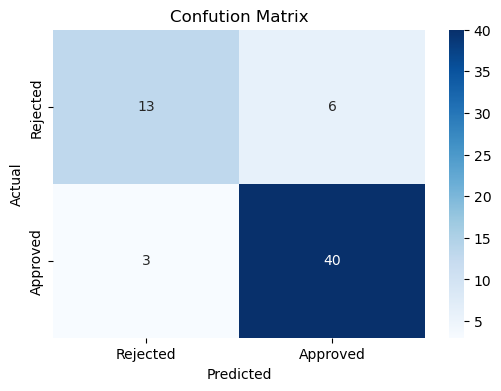

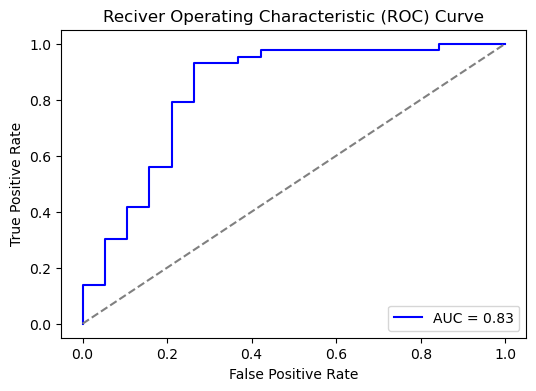

In [27]:
# Plot the Results
# Load the trained model
model_pipeline = joblib.load('loan_logreg_model.pkl')

train_predts = model_pipeline.predict(X_train)
val_predts = model_pipeline.predict(X_val)
test_predts = model_pipeline.predict(X_test)

# Print the Accuracies and Classification report
print("Training Accuracy:", accuracy_score(y_train, train_predts))
print("Validation Accuracy:", accuracy_score(y_val, val_predts))
print("Test Accuracy:", accuracy_score(y_test, test_predts))
print("\nClassification Report\n", classification_report(y_test, test_predts))

# Confusion Matrix
cm_test = confusion_matrix(y_test, test_predts)
plt.figure(figsize=(6,4))
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Rejected', 'Approved'],
            yticklabels=['Rejected', 'Approved'])
plt.title('Confution Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

# ROC Curve
y_test_probs = model_pipeline.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_test_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, color='blue', label=f'AUC = {roc_auc:.2f}')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Reciver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.show()

In [17]:
# Metrics evaluation
y_test_probs = model_pipeline.predict_proba(X_test)[:, 1]
test_preds = (y_test_probs >= 0.5).astype(int)

tn, fp, fn, tp = confusion_matrix(y_test, test_preds).ravel()

fpr = fp / (fp + tn)
tpr = tp / (tp + fn)
fnr = fn / (fn + tp)
tnr = tn / (tn + fp)

print(f"False Positive Rate (FPR): {fpr:.4f}")
print(f"True Positive Rate (TPR/ Recall): {tpr:.4f}")
print(f"False Negative Rate (FNR): {fnr:.4f}")
print(f"True Negative Rate (TNR/ Specificity): {tnr:.4f}")

False Positive Rate (FPR): 0.3158
True Positive Rate (TPR/ Recall): 0.9302
False Negative Rate (FNR): 0.0698
True Negative Rate (TNR/ Specificity): 0.6842


## Test Data Evaluation

In [20]:
# Load the test dataset
test_data_frame = pd.read_csv("test_loan.csv")

loan_ids = test_data_frame['Loan_ID']
X_test = test_data_frame.drop('Loan_ID', axis=1)

test_preds = model_pipeline.predict(X_test)
test_probs = model_pipeline.predict_proba(X_test)[:, 1]

results = pd.DataFrame({
    'Loan_ID': loan_ids,
    'Predicted_Status': ['Y' if x == 1 else 'N' for x in test_preds],
    'Approval_Probability': test_probs,
    'Confidence': ['High' if x > 0.7 else 'Medium' if x > 0.5 else 'Low' for x in test_probs]
})

results = pd.concat([results, test_data_frame.reset_index(drop=True)], axis=1)

# Save the csv file
results.to_csv('loan_predictions_logreg.csv', index=False)

# Display sample predictions
print("\nPredictions Results:")
print(results[['Loan_ID', 'Predicted_Status', 'Approval_Probability', 'Confidence']].head(5))



Predictions Results:
    Loan_ID   Loan_ID Predicted_Status  Approval_Probability Confidence
0  LP001015  LP001015                Y              0.812469       High
1  LP001022  LP001022                Y              0.738263       High
2  LP001031  LP001031                Y              0.872382       High
3  LP001035  LP001035                Y              0.873840       High
4  LP001051  LP001051                Y              0.604894     Medium
